<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 11 - Mall Segmentation Cluster

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [4]:
le = LabelEncoder()

In [5]:
df["Gender"] = le.fit_transform(df["Gender"])
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [6]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

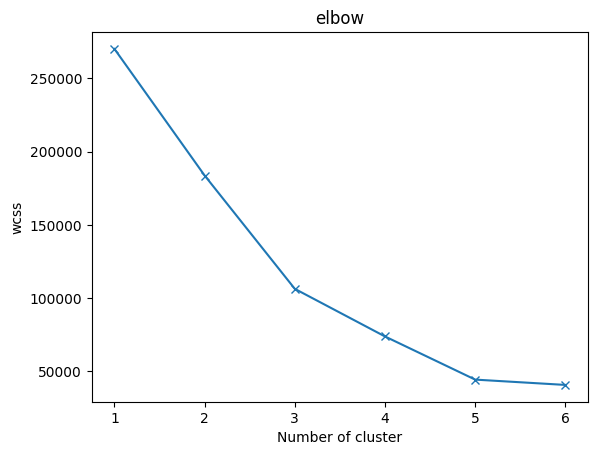

In [7]:
wcss=[]
for k in range(1,7):
  km = KMeans(n_clusters=k,random_state=42)
  km.fit(X)
  wcss.append(km.inertia_)
plt.plot(range(1,7),wcss,marker='x')
plt.title("elbow")
plt.xlabel("Number of cluster")
plt.ylabel("wcss")
plt.show()

In [8]:
model = KMeans(n_clusters=5,random_state=0)

In [9]:
df["cluster"]= model.fit_predict(X)

In [10]:
centroids = model.cluster_centers_

In [11]:
print(pd.DataFrame(centroids,columns=X.columns))

   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           88.200000               17.114286
3           26.304348               20.913043
4           25.727273               79.363636


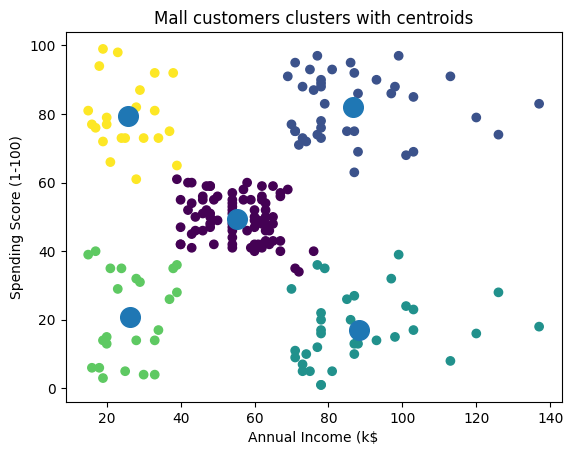

In [12]:
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],c=df["cluster"])
plt.scatter(centroids[:,0],centroids[:,1],marker='o',s=200)
plt.xlabel("Annual Income (k$")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall customers clusters with centroids")
plt.show()